# Minimal mmWave Group-Testing Attach Experiments

This notebook runs **sanity checks** and **Monte Carlo experiments** for the minimal mmWave initial-attach simulator.

It compares:

- **Exhaustive sweep**
- **Two-stage group testing**

The simulator assumes:

- single gNB
- single static UE per episode
- 121 pencil beams from **-60° to 60°**
- predefined **non-contiguous** group-test beam patterns
- scalar **Rician** channel
- **SNR-only** UE feedback
- simplified logical **RACH** procedure


## 1. Setup

This cell adds `./modules` to the import path and loads the simulator modules.

It first tries:

- `./modules`

and then falls back to:

- `../modules`

so the notebook can be run either from the project root or from a subfolder like `notebooks/`.


In [1]:
import os
import sys
from pathlib import Path

MODULE_DIR = Path("./modules").resolve()
if not MODULE_DIR.exists():
    MODULE_DIR = Path("../modules").resolve()

if not MODULE_DIR.exists():
    raise FileNotFoundError(
        "Could not find a 'modules' directory. "
        "Run this notebook from the project root, or place it in a folder whose parent contains 'modules'."
    )

if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

print(f"Using modules from: {MODULE_DIR}")


Using modules from: /home/narend/code/group_testing/modules


In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import SimulationConfig
from experiments import (
    build_simulator,
    episode_to_dict,
    run_baseline_comparison,
    run_many,
    run_threshold_sweep,
)
from metrics import summarize_by_range, summarize_methods


## 2. Build the simulator

You can edit the configuration values below before running the experiments.


In [3]:
cfg = SimulationConfig(
    seed=7,
    num_episodes=300,
)

sim = build_simulator(cfg)
codebook = sim.codebook
geometry = sim.geometry
channel = sim.channel
measurement = sim.measurement
policies = sim.policies
rach = sim.rach

print(cfg.summary())
print(codebook.summary())


SimulationConfig(seed=7, episodes=300, BeamConfig(num_beams=121, sector=[-60.0, 60.0] deg, beamwidth=12.0 deg, group_patterns=11, non_contiguous=11), range=[10.0, 100.0] m, blockage_prob=0.0)
BeamCodebook(num_beams=121, groups=11, non_contiguous_groups=11, beamwidth=12.0 deg)


## 3. Single-episode sanity check

This section runs one fixed UE scenario for both methods with the **same random seed**, so you can inspect:

- selected beam
- oracle beam
- attach status
- number of probes
- RACH trace


In [4]:
theta_deg = 17.0
range_m = 45.0
blocked = False

rng = np.random.default_rng(123)
ep_gt = sim.run_group_testing_episode(
    rng=rng,
    force_theta_deg=theta_deg,
    force_range_m=range_m,
    blocked=blocked,
)

rng = np.random.default_rng(123)
ep_ex = sim.run_exhaustive_episode(
    rng=rng,
    force_theta_deg=theta_deg,
    force_range_m=range_m,
    blocked=blocked,
)

pd.DataFrame([episode_to_dict(ep_ex), episode_to_dict(ep_gt)])


,method,ue_theta_deg,ue_range_m,blocked,selected_beam_index,oracle_best_beam_index,beam_index_error,selected_equals_oracle,final_snr_db,num_search_probes,num_total_probes,attached,rach_fail_state,selected_group_name,num_coarse_probes,num_fine_probes,candidate_size
0,exhaustive,17.0,45.0,False,77,77,0,True,14.31493,121,121,True,None,NaN,NaN,NaN,NaN
1,group_testing,17.0,45.0,False,77,77,0,True,14.31493,22,22,True,None,grp_mod11_00,11.0,11.0,11.0


In [5]:
def rach_trace_df(ep):
    rows = []
    for step in ep.rach_result.steps:
        rows.append(
            {
                "state": step.state_name,
                "beam_label": step.beam_label,
                "snr_db": step.snr_db,
                "detected": step.detected,
                "status": step.status,
                "note": step.note,
            }
        )
    return pd.DataFrame(rows)

print("Exhaustive RACH trace")
display(rach_trace_df(ep_ex))

print("Group-testing RACH trace")
display(rach_trace_df(ep_gt))


Exhaustive RACH trace


,state,beam_label,snr_db,detected,status,note
0,SEARCH,b077,14.31493,True,SUCCESS,Exhaustive sweep completed.
1,MSG1,b077,14.31493,True,SUCCESS,Logical RACH step on selected pencil beam.
2,MSG2,b077,14.31493,True,SUCCESS,Logical RACH step on selected pencil beam.
3,MSG3,b077,14.31493,True,SUCCESS,Logical RACH step on selected pencil beam.
4,FINE_LOCK,b077,14.31493,True,SUCCESS,No additional refinement needed after exhausti...
5,MSG4,b077,14.31493,True,SUCCESS,Final ACK on selected pencil beam.
6,ATTACHED,b077,14.31493,True,SUCCESS,Attach completed successfully.


Group-testing RACH trace


,state,beam_label,snr_db,detected,status,note
0,SEARCH,grp_mod11_00,4.67403,True,SUCCESS,Coarse group probing completed.
1,MSG1,grp_mod11_00,4.67403,True,SUCCESS,Logical coarse-beam RACH step.
2,MSG2,grp_mod11_00,4.67403,True,SUCCESS,Logical coarse-beam RACH step.
3,MSG3,grp_mod11_00,4.67403,True,SUCCESS,Logical coarse-beam RACH step.
4,FINE_LOCK,b077,14.31493,True,SUCCESS,Fine beam lock within shortlisted candidate set.
5,MSG4,b077,14.31493,True,SUCCESS,Final ACK on locked pencil beam.
6,ATTACHED,b077,14.31493,True,SUCCESS,Attach completed successfully.


## 4. Single-episode diagnostic plots

The next cell plots:

- the **oracle pencil-beam SNR** over all 121 beams
- the **coarse group-test SNRs**
- the selected group-testing candidate beams


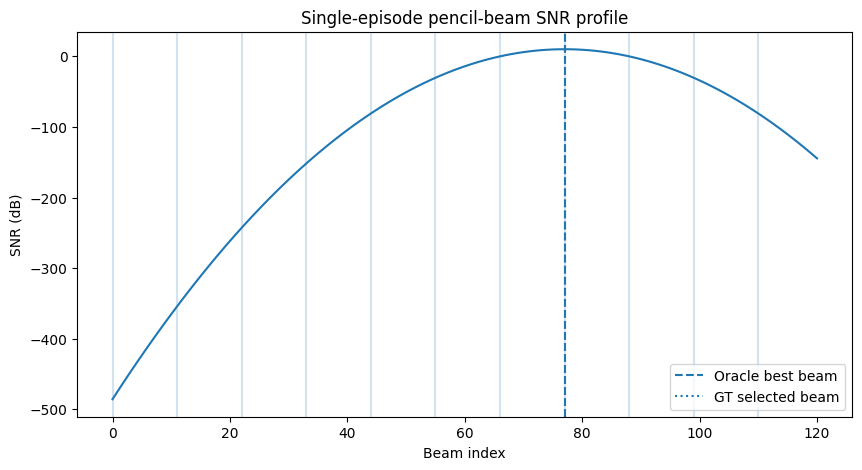

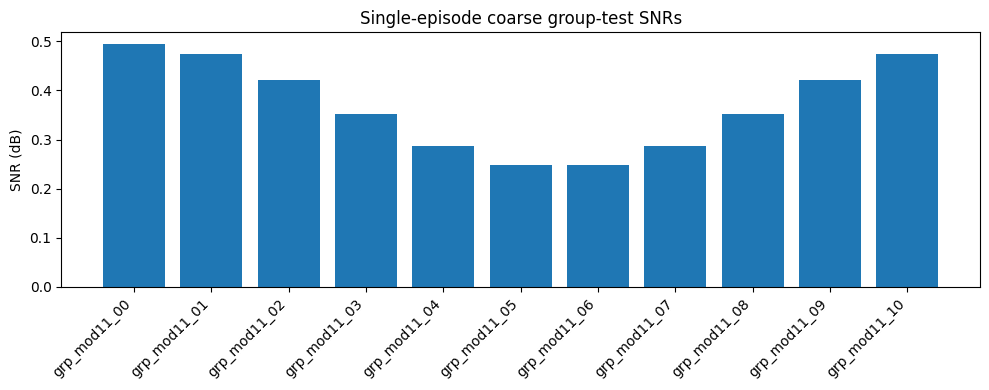

In [6]:
rng = np.random.default_rng(123)
fading = channel.sample_fading(rng=rng, range_m=range_m, blocked=blocked)

ue = geometry.sample_ue(
    force_theta_deg=theta_deg,
    force_range_m=range_m,
    blocked=blocked,
)

oracle_snr_db = channel.oracle_pencil_snr_vector_db(ue, fading=fading)
coarse_snr_db, group_names = channel.group_snr_vector_db(ue, fading=fading)

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(np.arange(len(oracle_snr_db)), oracle_snr_db)
ax.axvline(ep_ex.oracle_best_beam_index, linestyle="--", label="Oracle best beam")
ax.axvline(ep_gt.selected_beam_index, linestyle=":", label="GT selected beam")
for idx in ep_gt.search_result.candidate_indices:
    ax.axvline(idx, alpha=0.2)
ax.set_xlabel("Beam index")
ax.set_ylabel("SNR (dB)")
ax.set_title("Single-episode pencil-beam SNR profile")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(1, 1, 1)
ax.bar(np.arange(len(group_names)), coarse_snr_db)
ax.set_xticks(np.arange(len(group_names)))
ax.set_xticklabels(group_names, rotation=45, ha="right")
ax.set_ylabel("SNR (dB)")
ax.set_title("Single-episode coarse group-test SNRs")
plt.tight_layout()
plt.show()


## 5. Monte Carlo runner

This helper runs many episodes and collects a flat results table.


In [ ]:
# Imported from experiments.py so experiment runs are reusable outside this notebook.
run_many


## 6. Baseline experiment

This runs both methods over many random UE placements.


In [7]:
N_EPISODES = 300

df = run_baseline_comparison(
    sim,
    N_EPISODES,
    seed=100,
    coarse_decode="max_group",
    group_combine="equal_power",
)

df_ex = df[df["method"] == "exhaustive"].copy()
df_gt = df[df["method"] == "group_testing"].copy()

df.head()


,episode,method,ue_theta_deg,ue_range_m,blocked,selected_beam_index,oracle_best_beam_index,beam_index_error,selected_equals_oracle,final_snr_db,num_search_probes,num_total_probes,attached,rach_fail_state,selected_group_name,num_coarse_probes,num_fine_probes,candidate_size
0,0,exhaustive,-24.298085,80.897495,False,36,36,0,True,6.987972,121,121,True,None,None,NaN,NaN,NaN
1,1,exhaustive,31.235422,28.041658,False,91,91,0,True,13.978109,121,121,True,None,None,NaN,NaN,NaN
2,2,exhaustive,-11.848746,64.207886,False,48,48,0,True,6.749092,121,121,True,None,None,NaN,NaN,NaN
3,3,exhaustive,29.772949,59.541754,False,90,90,0,True,11.937164,121,121,True,None,None,NaN,NaN,NaN
4,4,exhaustive,33.161144,63.454131,False,93,93,0,True,8.481462,121,121,True,None,None,NaN,NaN,NaN


## 7. Aggregate metrics

These summaries are the main quantities you will likely report.


In [ ]:
summary = summarize_methods(df)
summary


## 8. Comparison plots

These are simple plots for the baseline comparison.


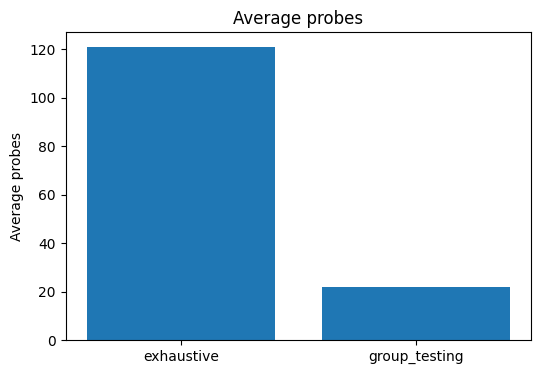

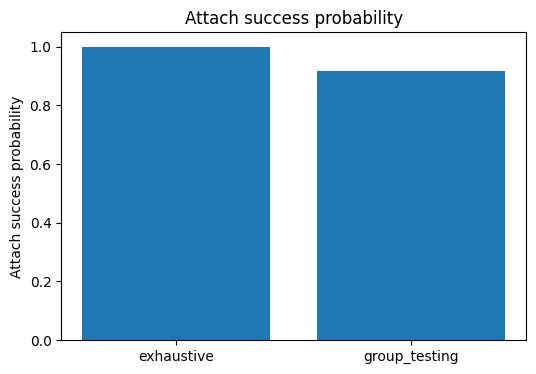

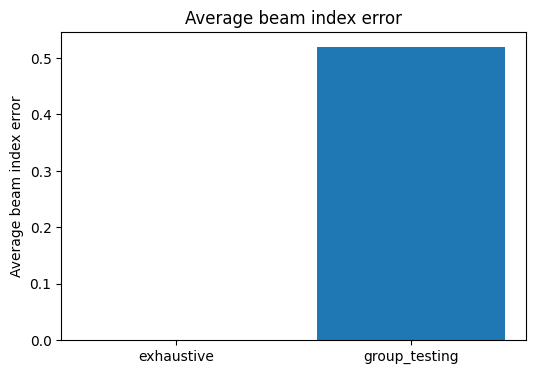

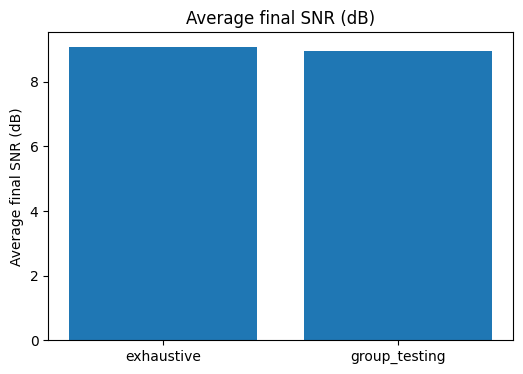

In [8]:
plot_cols = [
    ("avg_probes", "Average probes"),
    ("attach_success", "Attach success probability"),
    ("avg_beam_error", "Average beam index error"),
    ("avg_final_snr_db", "Average final SNR (dB)"),
]

summary = summarize_methods(df)

for col, title in plot_cols:
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(1, 1, 1)
    ax.bar(summary["method"], summary[col])
    ax.set_title(title)
    ax.set_ylabel(title)
    plt.show()


## 9. Range-sliced analysis

This section looks at how performance changes with UE range.


In [ ]:
range_summary = summarize_by_range(df)
range_summary.head(10)


NameError: name 'range_summary' is not defined

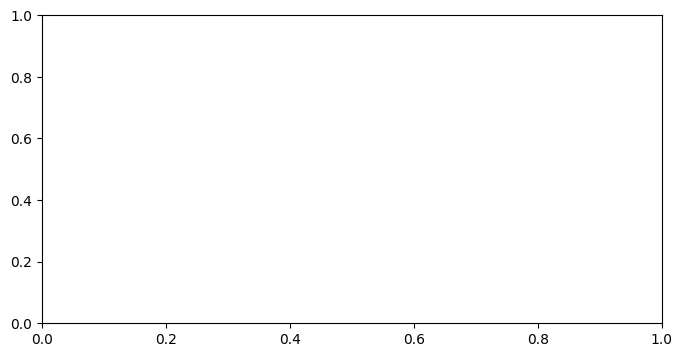

In [9]:
for metric in ["attach_success", "avg_beam_error", "avg_final_snr_db"]:
    fig = plt.figure(figsize=(8, 4))
    ax = fig.add_subplot(1, 1, 1)

    for method in range_summary["method"].unique():
        sub = range_summary[range_summary["method"] == method]
        ax.plot(sub["range_bin_m"].astype(str), sub[metric], marker="o", label=method)

    ax.set_title(metric)
    ax.set_xlabel("UE range bin (m)")
    ax.set_ylabel(metric)
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 10. Optional threshold sweep

You can use this section to see how the attach behavior changes with the detection threshold.

It rebuilds the simulator for each threshold.


In [ ]:
thresholds_db = [-10, -7, -5, -3, 0]

df_threshold = run_threshold_sweep(
    thresholds_db,
    n_episodes=200,
    seed=200,
    config_seed=7,
    config_num_episodes=300,
)

df_threshold


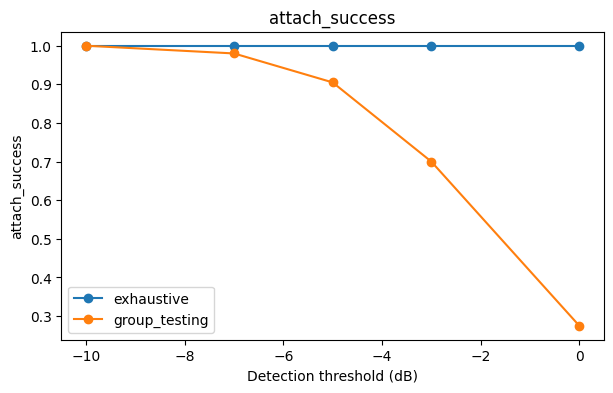

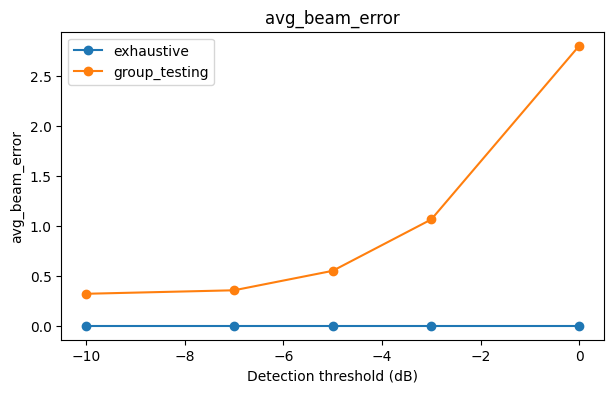

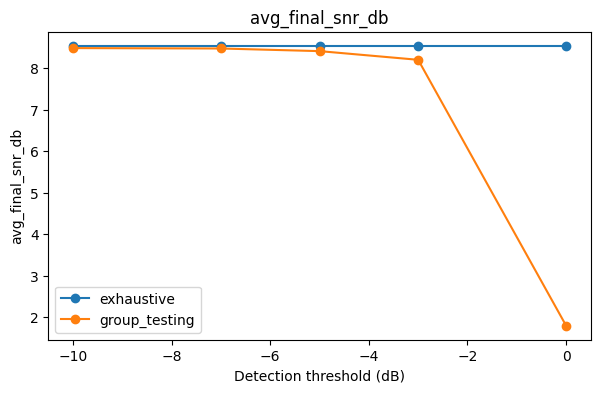

In [17]:
for metric in ["attach_success", "avg_beam_error", "avg_final_snr_db"]:
    fig = plt.figure(figsize=(7, 4))
    ax = fig.add_subplot(1, 1, 1)

    for method in df_threshold["method"].unique():
        sub = df_threshold[df_threshold["method"] == method]
        ax.plot(sub["threshold_db"], sub[metric], marker="o", label=method)

    ax.set_title(metric)
    ax.set_xlabel("Detection threshold (dB)")
    ax.set_ylabel(metric)
    ax.legend()
    plt.show()


## 11. Save results

Uncomment the lines below if you want to save the experiment tables to disk.


In [ ]:
# df.to_csv("baseline_results.csv", index=False)
# summary.to_csv("baseline_summary.csv", index=False)
# range_summary.to_csv("range_summary.csv", index=False)
# df_threshold.to_csv("threshold_sweep_summary.csv", index=False)
